In [1]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 50
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

2

[('50a1', [(1, 1), (2, -1), (3, 1), (4, 1), (5, 0)]), ('50b1', [(1, 1), (2, 1), (3, -1), (4, 1), (5, 0)])]

('50a1', [(1, 1), (2, -1), (3, 1), (4, 1), (5, 0)])

[(1, 1), (2, -1), (3, 1), (4, 1), (5, 0)]


In [1]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 50
bound =500
output = elliptic_fourier_expansions(level, bound)
data=output[1]
label = data[0]
expansion=data[1]
print("label:", label)
coeffs_list=[pair[1] for pair in expansion]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run11april26no21.txt', 'wb') as wfile:
    pickle.dump(expansion, wfile) 
    
with open('/Users/barrybrent/data2/run11april26no22.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 50b1
(1, 1)
(2, 1)
(3, -5)
(4, 9)
(5, -4)
(6, -17)
(7, 22)
(8, -7)
(9, -50)
(10, 96)
(11, -87)
(12, -105)
(13, 404)
(14, -482)
(15, -40)
(16, 1113)
(17, -1869)
(18, 766)
(19, 2889)
(20, -6656)
(21, 5098)
(22, 6029)
(23, -22286)
(24, 25415)
(25, 5696)
(26, -67196)
(27, 105601)
(28, -34130)
(29, -177856)
(30, 388608)
(31, -281014)
(32, -382183)
(33, 1303011)
(34, -1423613)
(35, -439408)
(36, 3979758)
(37, -5991594)
(38, 1543637)
(39, 10793180)
(40, -22415872)
(41, 15010757)
(42, 24169282)
(43, -76217972)
(44, 79254085)
(45, 32685620)
(46, -235902374)
(47, 340190372)
(48, -65269209)
(49, -651995987)
(50, 1290869696)
(51, -795561687)
(52, -1512839644)
(53, 4446525154)
(54, -4392041579)
(55, -2313476312)
(56, 13954315662)
(57, -19267718973)
(58, 2360971520)
(59, 39270439944)
(60, -74212079360)
(61, 41710213818)
(62, 94035822562)
(63, -258946395548)
(64, 242399473817)
(65, 158192035504)
(66, -823673298685)
(67, 1088556859369)
(68, -53838640101)
(69, -2358195748418)
(70, 4258320322688)

1 4.5351187388102214e-05
2 9.005467096964518e-05
3 0.00010447104771931966
4 0.00011976957321166993
5 0.00013840198516845703
6 0.00017353296279907227
7 0.00021103223164876302
8 0.000255886713663737
9 0.0003028710683186849
10 0.000413052241007487
11 0.0004780054092407227
12 0.0005513350168863932
13 0.0006371657053629557
14 0.0007335861523946126
15 0.0008563836415608724
16 0.0009848356246948242
17 0.0011202335357666016
18 0.0012917160987854005
19 0.001467601458231608
20 0.001692020893096924
21 0.0019050041834513347
22 0.0021648009618123374
23 0.002458771069844564
24 0.0027081688245137532
25 0.0030222336451212564
26 0.003370821475982666
27 0.003746803601582845
28 0.0041225671768188475
29 0.004542485872904459
30 0.004961784680684408
31 0.005466771125793457
32 0.0059890349706013995
33 0.006531234582265218
34 0.007161136468251546
35 0.00779271920522054
36 0.00848620335261027
37 0.009262283643086752
38 0.010068786144256592
39 0.0109466552734375
40 0.011795469125111898
41 0.012738104661305745
4

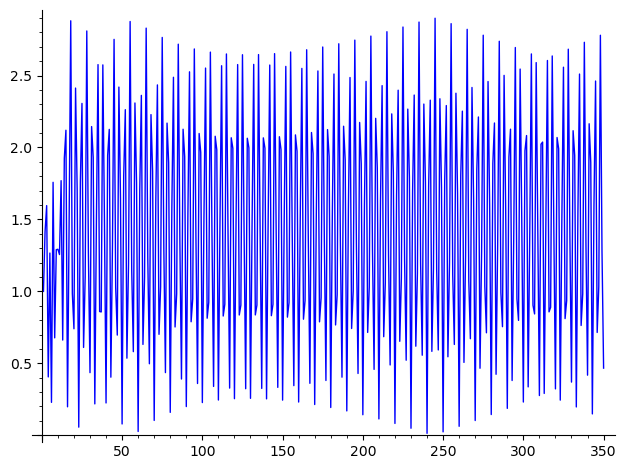

In [3]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time

start=time.time()
with open('/Users/barrybrent/data2/run11april26no22.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
args_list=[]

dets=[]

for n in range(1, 351):
    print(n, (time.time()-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    
    minn = min(aar)  
    mins_list.append((n,minn))

   


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()


with open('/Users/barrybrent/data2/run11april26no23.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run11april26no24.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run11april26no25.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped
